# Rabi-Oszillationen im Z-Spektrum

Bei sehr kurzer Sättigungszeit ($t_{sat} \ll T_2$) erreicht das Spinsystem **keinen Steady-State**.
Stattdessen dreht das effektive Feld die Magnetisierung um den Winkel $\Omega_{eff} \cdot t_{sat}$:

$$\Omega_{eff}(\Delta\omega) = \sqrt{\omega_1^2 + \Delta\omega^2}$$

$$M_z = \cos^2\theta + \sin^2\theta \cdot \cos(\Omega_{eff} \cdot t_{sat}), \qquad \theta = \arctan\!\left(\frac{\omega_1}{\Delta\omega}\right)$$

Da $\Omega_{eff}$ vom Offset abhängt, entsteht als Funktion des Offsets ein **Oszillationsmuster**.
Mit steigendem $|\Delta\omega|$ wächst $\Omega_{eff}$ → mehr Rotationen in $t_{sat}$ → höhere räumliche Frequenz.

Zum Vergleich: bei $t_{sat} = 2\,\text{s} \gg T_2 = 71\,\text{ms}$ ist die Nutation längst ausgedämpft → glatter Lorentzian.

In [36]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pypulseq as pp
from bmc.utils.seq.write import write_seq
from bmc.simulate import simulate_zspec

In [37]:
wdir   = Path().resolve().parent
folder = wdir / "seq_lib"

sys_opts = pp.Opts(
    max_grad=500, grad_unit="mT/m",
    max_slew=1e9, slew_unit="T/m/s",
    rf_ringdown_time=0, rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)

B0           = 17       # [T]
b1_sat_hz    = 128.0    # [Hz]  (~3 µT at 17T)
t_sat_short  = 2e-3     # [s]   << T2, << 1/k  →  Rabi, kein Exchange-Dip
t_sat_medium = 50e-3    # [s]    ~ T2,  > 1/k  →  Rabi + Exchange-Dip
t_sat_long   = 2.0      # [s]   >> T2, >> 1/k  →  Steady-State, klarer Lorentzian + CEST
offset_range = 10       # [ppm]
n_offsets    = 300      # dicht samplen um Oszillationen aufzulösen

GAMMA_HZ = sys_opts.gamma * 1e-6   # [MHz/T]
LARMOR   = B0 * GAMMA_HZ           # [MHz] = Hz/ppm

k_amide  = 150    # [Hz]  Austauschrate Amid → Wasser (aus config)
T2_water = 0.071  # [s]

offsets_ppm = np.append(300, np.linspace(-offset_range, offset_range, n_offsets))

print(f"B1            : {b1_sat_hz:.1f} Hz  ({b1_sat_hz/42.576:.2f} µT at 17T)")
print(f"T2 Wasser     : {T2_water*1e3:.0f} ms  |  1/k_amide = {1/k_amide*1e3:.1f} ms")
print()
print(f"t_sat short   : {t_sat_short*1e3:.0f} ms   k*t={k_amide*t_sat_short:.2f}  t/T2={t_sat_short/T2_water:.2f}  → Rabi, kein CEST")
print(f"t_sat medium  : {t_sat_medium*1e3:.0f} ms   k*t={k_amide*t_sat_medium:.1f}   t/T2={t_sat_medium/T2_water:.2f}  → Rabi + CEST")
print(f"t_sat long    : {t_sat_long:.0f} s     k*t={k_amide*t_sat_long:.0f}   t/T2={t_sat_long/T2_water:.0f}   → Steady-State")

B1            : 128.0 Hz  (3.01 µT at 17T)
T2 Wasser     : 71 ms  |  1/k_amide = 6.7 ms

t_sat short   : 2 ms   k*t=0.30  t/T2=0.03  → Rabi, kein CEST
t_sat medium  : 50 ms   k*t=7.5   t/T2=0.70  → Rabi + CEST
t_sat long    : 2 s     k*t=300   t/T2=28   → Steady-State


### Sequenzen erstellen

In [38]:
def make_zspec_seq(b1_hz, t_sat, offsets_ppm, larmor, sys_opts, folder, seqid, author="DANIEL MIKSCH"):
    defs = {
        "b0": B0, "m0_offset": 300, "n_ETM": 1,
        "freq": larmor,
        "offsets_ppm": offsets_ppm,
        "num_meas": offsets_ppm.size,
        "seq_id_string": seqid,
    }
    pseudo_adc = pp.make_adc(num_samples=1, duration=1e-3)
    seq = pp.Sequence()
    for off_hz in offsets_ppm * larmor:
        rf = pp.make_block_pulse(
            flip_angle=b1_hz * t_sat * 2 * np.pi,
            system=sys_opts, duration=t_sat,
            freq_offset=off_hz, phase_offset=0,
        )
        seq.add_block(rf)
        seq.add_block(pseudo_adc)
    ok, _ = seq.check_timing()
    assert ok, "Timing check failed"
    path = folder / f"{seqid}.seq"
    write_seq(seq=seq, seq_defs=defs, filename=path, author=author, use_matlab_names=True)
    print(f"Saved {path}  (TotalDur={seq.duration()[0]:.3f} s)")
    return path

seq_short  = make_zspec_seq(b1_sat_hz, t_sat_short,  offsets_ppm, LARMOR, sys_opts, folder, "zspec_rabi_short")
seq_medium = make_zspec_seq(b1_sat_hz, t_sat_medium, offsets_ppm, LARMOR, sys_opts, folder, "zspec_rabi_medium")
seq_long   = make_zspec_seq(b1_sat_hz, t_sat_long,   offsets_ppm, LARMOR, sys_opts, folder, "zspec_rabi_long")

Saved /Users/danielmiksch/JupyterLab/optim/seq_lib/zspec_rabi_short.seq  (TotalDur=0.903 s)
Saved /Users/danielmiksch/JupyterLab/optim/seq_lib/zspec_rabi_medium.seq  (TotalDur=15.351 s)
Saved /Users/danielmiksch/JupyterLab/optim/seq_lib/zspec_rabi_long.seq  (TotalDur=602.301 s)


### Simulation

In [39]:
config = wdir / 'sim_lib' / 'config_1pool.yaml'

offsets_short,  mz_short  = simulate_zspec(config, seq_short,  norm_threshold=295)
offsets_medium, mz_medium = simulate_zspec(config, seq_medium, norm_threshold=295)
offsets_long,   mz_long   = simulate_zspec(config, seq_long,   norm_threshold=295)

Z-spectrum: 100%|██████████| 602/602 [00:00<00:00, 3751.88it/s]


### Vergleich: Rabi-Oszillationen vs. Steady-State

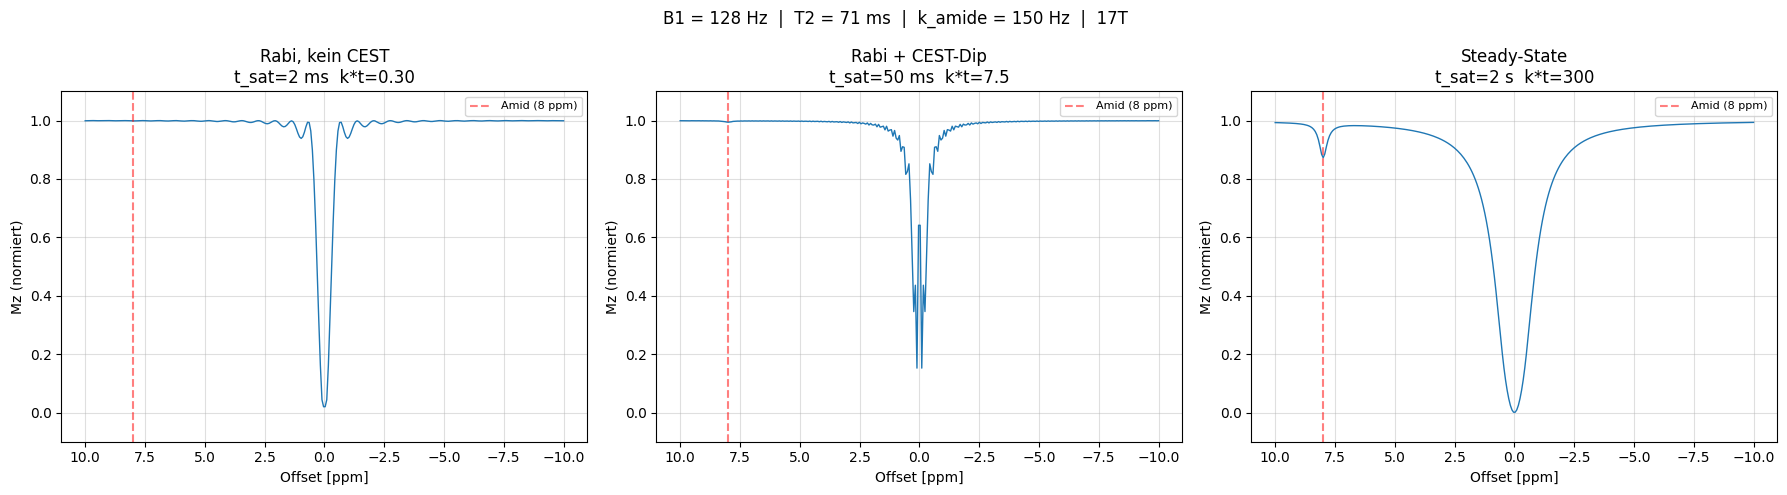

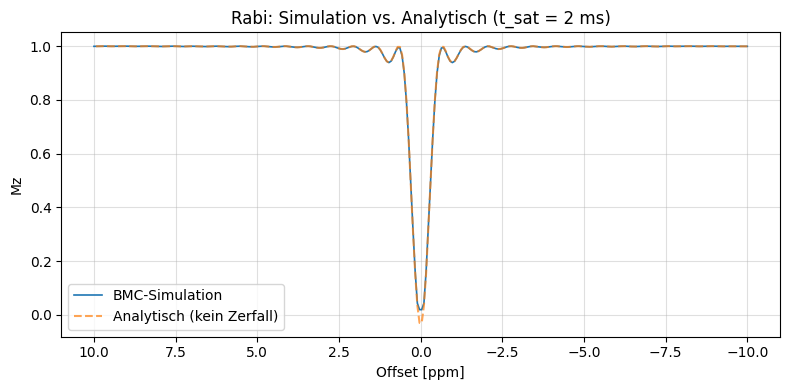

In [40]:
# Precompute titles — avoids literal newlines inside f-strings
title_s = f"Rabi, kein CEST\nt_sat={t_sat_short*1e3:.0f} ms  k*t={k_amide*t_sat_short:.2f}"
title_m = f"Rabi + CEST-Dip\nt_sat={t_sat_medium*1e3:.0f} ms  k*t={k_amide*t_sat_medium:.1f}"
title_l = f"Steady-State\nt_sat={t_sat_long:.0f} s  k*t={k_amide*t_sat_long:.0f}"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cases = [
    (axes[0], offsets_short,  mz_short,  title_s),
    (axes[1], offsets_medium, mz_medium, title_m),
    (axes[2], offsets_long,   mz_long,   title_l),
]

for ax, offsets, mz, title in cases:
    ax.plot(offsets, mz, linewidth=1.0)
    ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='Amid (8 ppm)')
    ax.invert_xaxis()
    ax.set_xlabel('Offset [ppm]')
    ax.set_ylabel('Mz (normiert)')
    ax.set_title(title)
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(f"B1 = {b1_sat_hz:.0f} Hz  |  T2 = {T2_water*1e3:.0f} ms  |  k_amide = {k_amide} Hz  |  17T", fontsize=12)
plt.tight_layout()
plt.show()

# analytische Kurve fuer kurzes t_sat (keine Relaxation)
fig2, ax2 = plt.subplots(figsize=(8, 4))
delta_hz    = offsets_short * LARMOR
omega1      = 2 * np.pi * b1_sat_hz
delta_rad   = 2 * np.pi * delta_hz
omega_eff   = np.sqrt(omega1**2 + delta_rad**2)
theta       = np.arctan2(omega1, delta_rad)
mz_analytic = np.cos(theta)**2 + np.sin(theta)**2 * np.cos(omega_eff * t_sat_short)

ax2.plot(offsets_short, mz_short,    label='BMC-Simulation', linewidth=1.2)
ax2.plot(offsets_short, mz_analytic, label='Analytisch (kein Zerfall)', linestyle='--', alpha=0.7)
ax2.invert_xaxis()
ax2.set_xlabel('Offset [ppm]')
ax2.set_ylabel('Mz')
ax2.set_title(f"Rabi: Simulation vs. Analytisch (t_sat = {t_sat_short*1e3:.0f} ms)")
ax2.legend()
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()